# Question 5: Neural Networks - MLP vs CNN on Images

## Objective
The goal of this task is to design, train, and evaluate simple neural networks for image classification.

## Dataset
The Fashion-MNIST dataset is used. It contains grayscale images of 10 clothing categories.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

np.random.seed(123)

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(X_train_full.shape)
print(y_train_full.shape)
print(X_test.shape)
print(y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

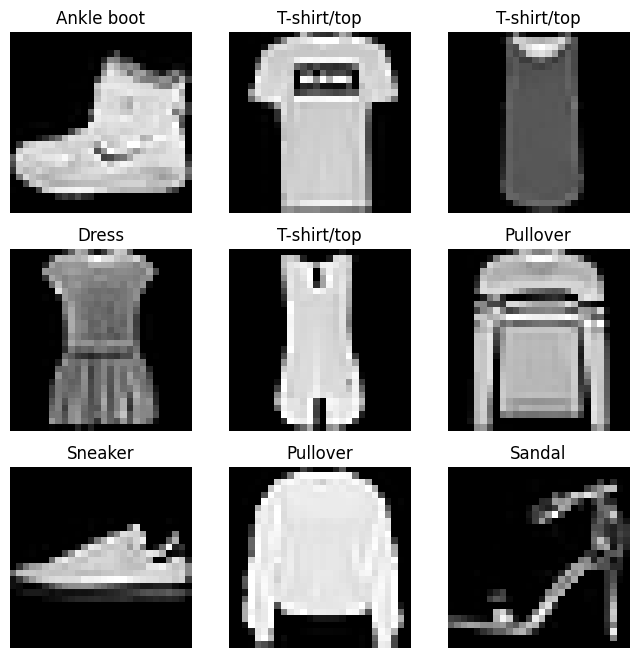

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.show()

## Data Preprocessing

###Normalize

In [ ]:
# Normalize (0-255 → 0-1)
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

Pixel values are normalized from the range [0,255] to [0,1] to improve training stability and performance.

###Train / Validation split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=123
)

###Label encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

The pixel values are normalized to the range [0,1]. The dataset is split into training and validation sets. Labels are one-hot encoded for neural network training.

## Multilayer Perceptron (MLP)

The MLP model uses fully connected layers. Since images are 2D, they are first flattened into one-dimensional vectors.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

mlp_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

In [ ]:
mlp_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_mlp = mlp_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7742 - loss: 0.6326 - val_accuracy: 0.8478 - val_loss: 0.4067
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8405 - loss: 0.4376 - val_accuracy: 0.8617 - val_loss: 0.3855
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8544 - loss: 0.4009 - val_accuracy: 0.8742 - val_loss: 0.3473
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8629 - loss: 0.3755 - val_accuracy: 0.8792 - val_loss: 0.3332
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8678 - loss: 0.3580 - val_accuracy: 0.8818 - val_loss: 0.3230
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8747 - loss: 0.3435 - val_accuracy: 0.8913 - val_loss: 0.3061
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8766 - loss: 0.3335 - val_accuracy: 0.8887 - val_loss: 0.3079
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8815 - loss: 0.3215 - val_accuracy:

## Convolutional Neural Network (CNN)

CNN models are designed to process image data by capturing spatial patterns such as edges and shapes using convolutional layers.

In [ ]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_cnn = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop_cnn]
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 98ms/step - accuracy: 0.7815 - loss: 0.6078 - val_accuracy: 0.8550 - val_loss: 0.3965
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.8626 - loss: 0.3835 - val_accuracy: 0.8840 - val_loss: 0.3243
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.8758 - loss: 0.3388 - val_accuracy: 0.8860 - val_loss: 0.3062
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.8871 - loss: 0.3071 - val_accuracy: 0.8968 - val_loss: 0.2776
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.8956 - loss: 0.2853 - val_accuracy: 0.8957 - val_loss: 0.2873
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9020 - loss: 0.2685 - val_accuracy: 0.9043 - val_loss: 0.2583
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9065 - loss: 0.2502 - val_accuracy: 0.9103 - val_loss: 0.2500
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9126 - loss: 0.2363 -

In [ ]:
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(X_test, y_test_cat)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test_cat)

print("MLP Test Accuracy:", mlp_test_acc)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8870 - loss: 0.3152
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9175 - loss: 0.2457
MLP Test Accuracy: 0.8870000243186951
CNN Test Accuracy: 0.9175000190734863


The CNN outperformed the MLP on the Fashion-MNIST test set. This is expected because CNNs preserve and exploit spatial information in images through convolutional filters, while MLPs flatten the image and lose local spatial structure. The CNN can learn patterns such as edges, shapes, and textures, making it more suitable for image classification.

##Macro F1

In [ ]:
from sklearn.metrics import f1_score

# MLP
y_pred_mlp = mlp_model.predict(X_test)
y_pred_mlp = y_pred_mlp.argmax(axis=1)

# CNN
y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = y_pred_cnn.argmax(axis=1)

# True labels
y_true = y_test

# F1
f1_mlp = f1_score(y_true, y_pred_mlp, average='macro')
f1_cnn = f1_score(y_true, y_pred_cnn, average='macro')

print("MLP Macro F1:", f1_mlp)
print("CNN Macro F1:", f1_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
MLP Macro F1: 0.886029888140699
CNN Macro F1: 0.91698152746427


## Confusion Matrix Analysis

Both models struggle to distinguish between visually similar classes such as shirts, t-shirts, and pullovers. However, the CNN model shows fewer misclassifications compared to the MLP.

The CNN achieves stronger diagonal values in the confusion matrix, indicating better classification performance across most classes.

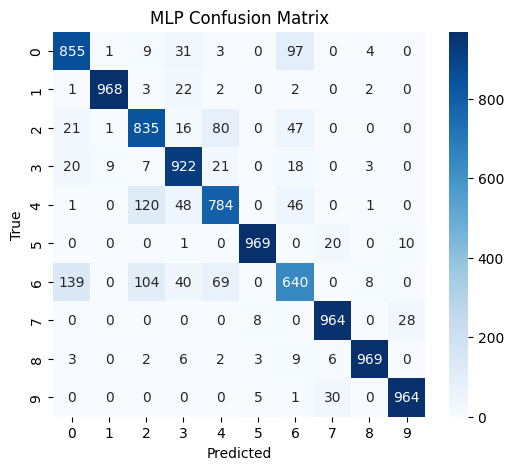

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# MLP
cm_mlp = confusion_matrix(y_true, y_pred_mlp)

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

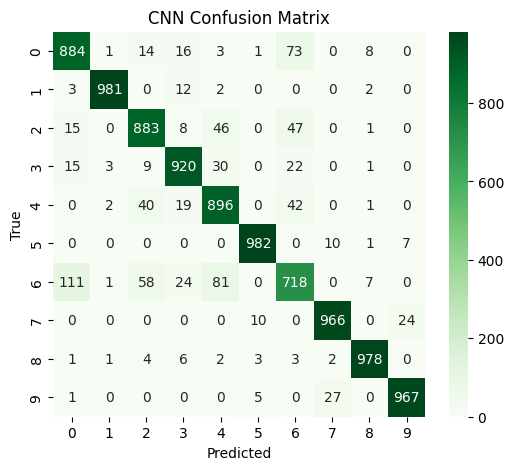

In [ ]:
# CNN
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Misclassified Examples Analysis

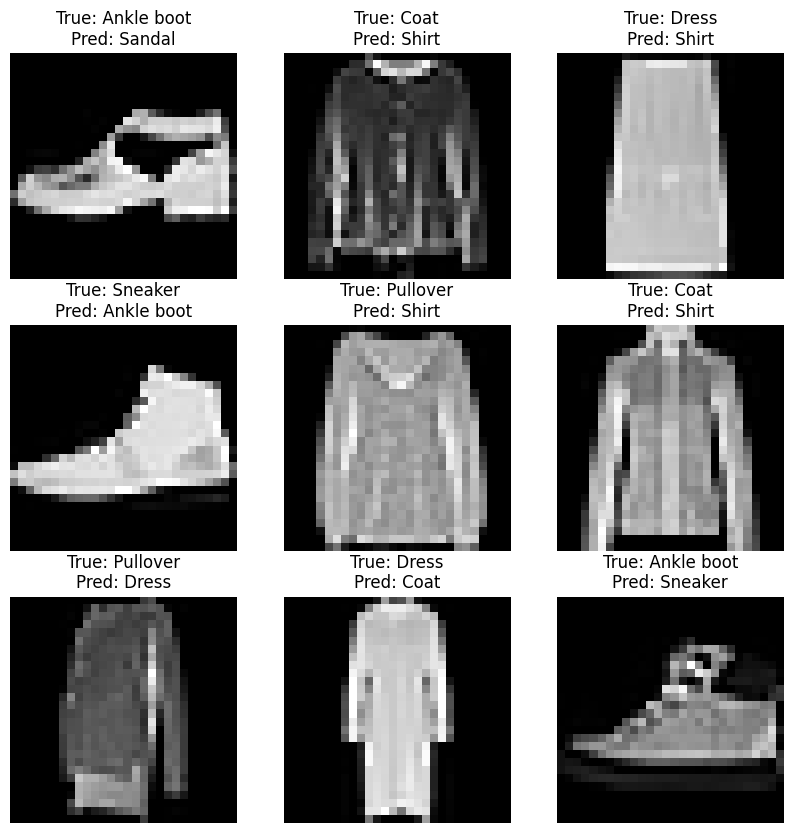

In [ ]:
#Find CNN's incorrect predictions
mis_idx = np.where(y_pred_cnn != y_true)[0]

plt.figure(figsize=(10,10))

for i in range(9):
    idx = mis_idx[i]
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_cnn[idx]]}")
    plt.axis('off')

plt.show()



The misclassified examples show that the model struggles to distinguish between visually similar classes. Most errors occur between categories with similar shapes, such as shirts, coats, and pullovers, as well as different types of footwear like sneakers and ankle boots.

This is mainly due to the low resolution (28x28) and grayscale nature of the images, which limits the amount of distinguishable detail. As a result, even human classification can be challenging for some cases.

## Conclusion

The MLP model achieved a test accuracy of approximately 0.887 and a macro F1-score of 0.886. The CNN model achieved higher performance with a test accuracy of approximately 0.917 and a macro F1-score of 0.917.
Confusion matrices showed that both models struggled with visually similar classes such as shirts, pullovers, and coats. However, the CNN model produced fewer misclassifications overall.
The results indicate that CNN outperforms MLP for image classification tasks. The MLP flattens the image into a one-dimensional vector, losing spatial information. In contrast, CNN preserves the spatial structure of the image and learns local features such as edges and shapes through convolutional layers.
Misclassified examples indicate that both models have difficulty distinguishing between visually similar categories, which is expected given the low resolution and grayscale nature of the dataset.
As a result CNN is preferred for image-based tasks due to its ability to capture spatial patterns and hierarchical features.
